# Analysis of the feature importance of the baseline models


Analyze the importance of the features in the baseline models to try to explain the models.
Use this information to improve the features of the models.

In [1]:
import core.constants as c
from core.feature_importance import (
    load_trained_models_and_results,
    load_dataset,
    compute_feature_importances_for_models,
    plot_feature_importances_by_model,
    plot_feature_vs_target_grid,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
results, trained_models = load_trained_models_and_results(c.RICKD_BASELINE_RESULTS_SUMMARY_FILE)

In [3]:
X_train, X_test, y_train, y_test = load_dataset(
    c.RICKD_BASELINE_X_TRAIN_FILE,
    c.RICKD_BASELINE_X_TEST_FILE,
    c.RICKD_BASELINE_Y_TRAIN_FILE,
    c.RICKD_BASELINE_Y_TEST_FILE,
)

In [4]:
all_feature_importance = compute_feature_importances_for_models(
    trained_models, X_test, y_test, random_state=RANDOM_STATE
)

Extracting feature importance for Logistic Regression...
Using coef_ for Logistic Regression...
Extracting feature importance for Random Forest...
Using feature_importances_ for Random Forest...
Extracting feature importance for XGBoost...
Using feature_importances_ for XGBoost...
Extracting feature importance for SVM...
Computing permutation importance for SVM...


## Feature Importance Visualization

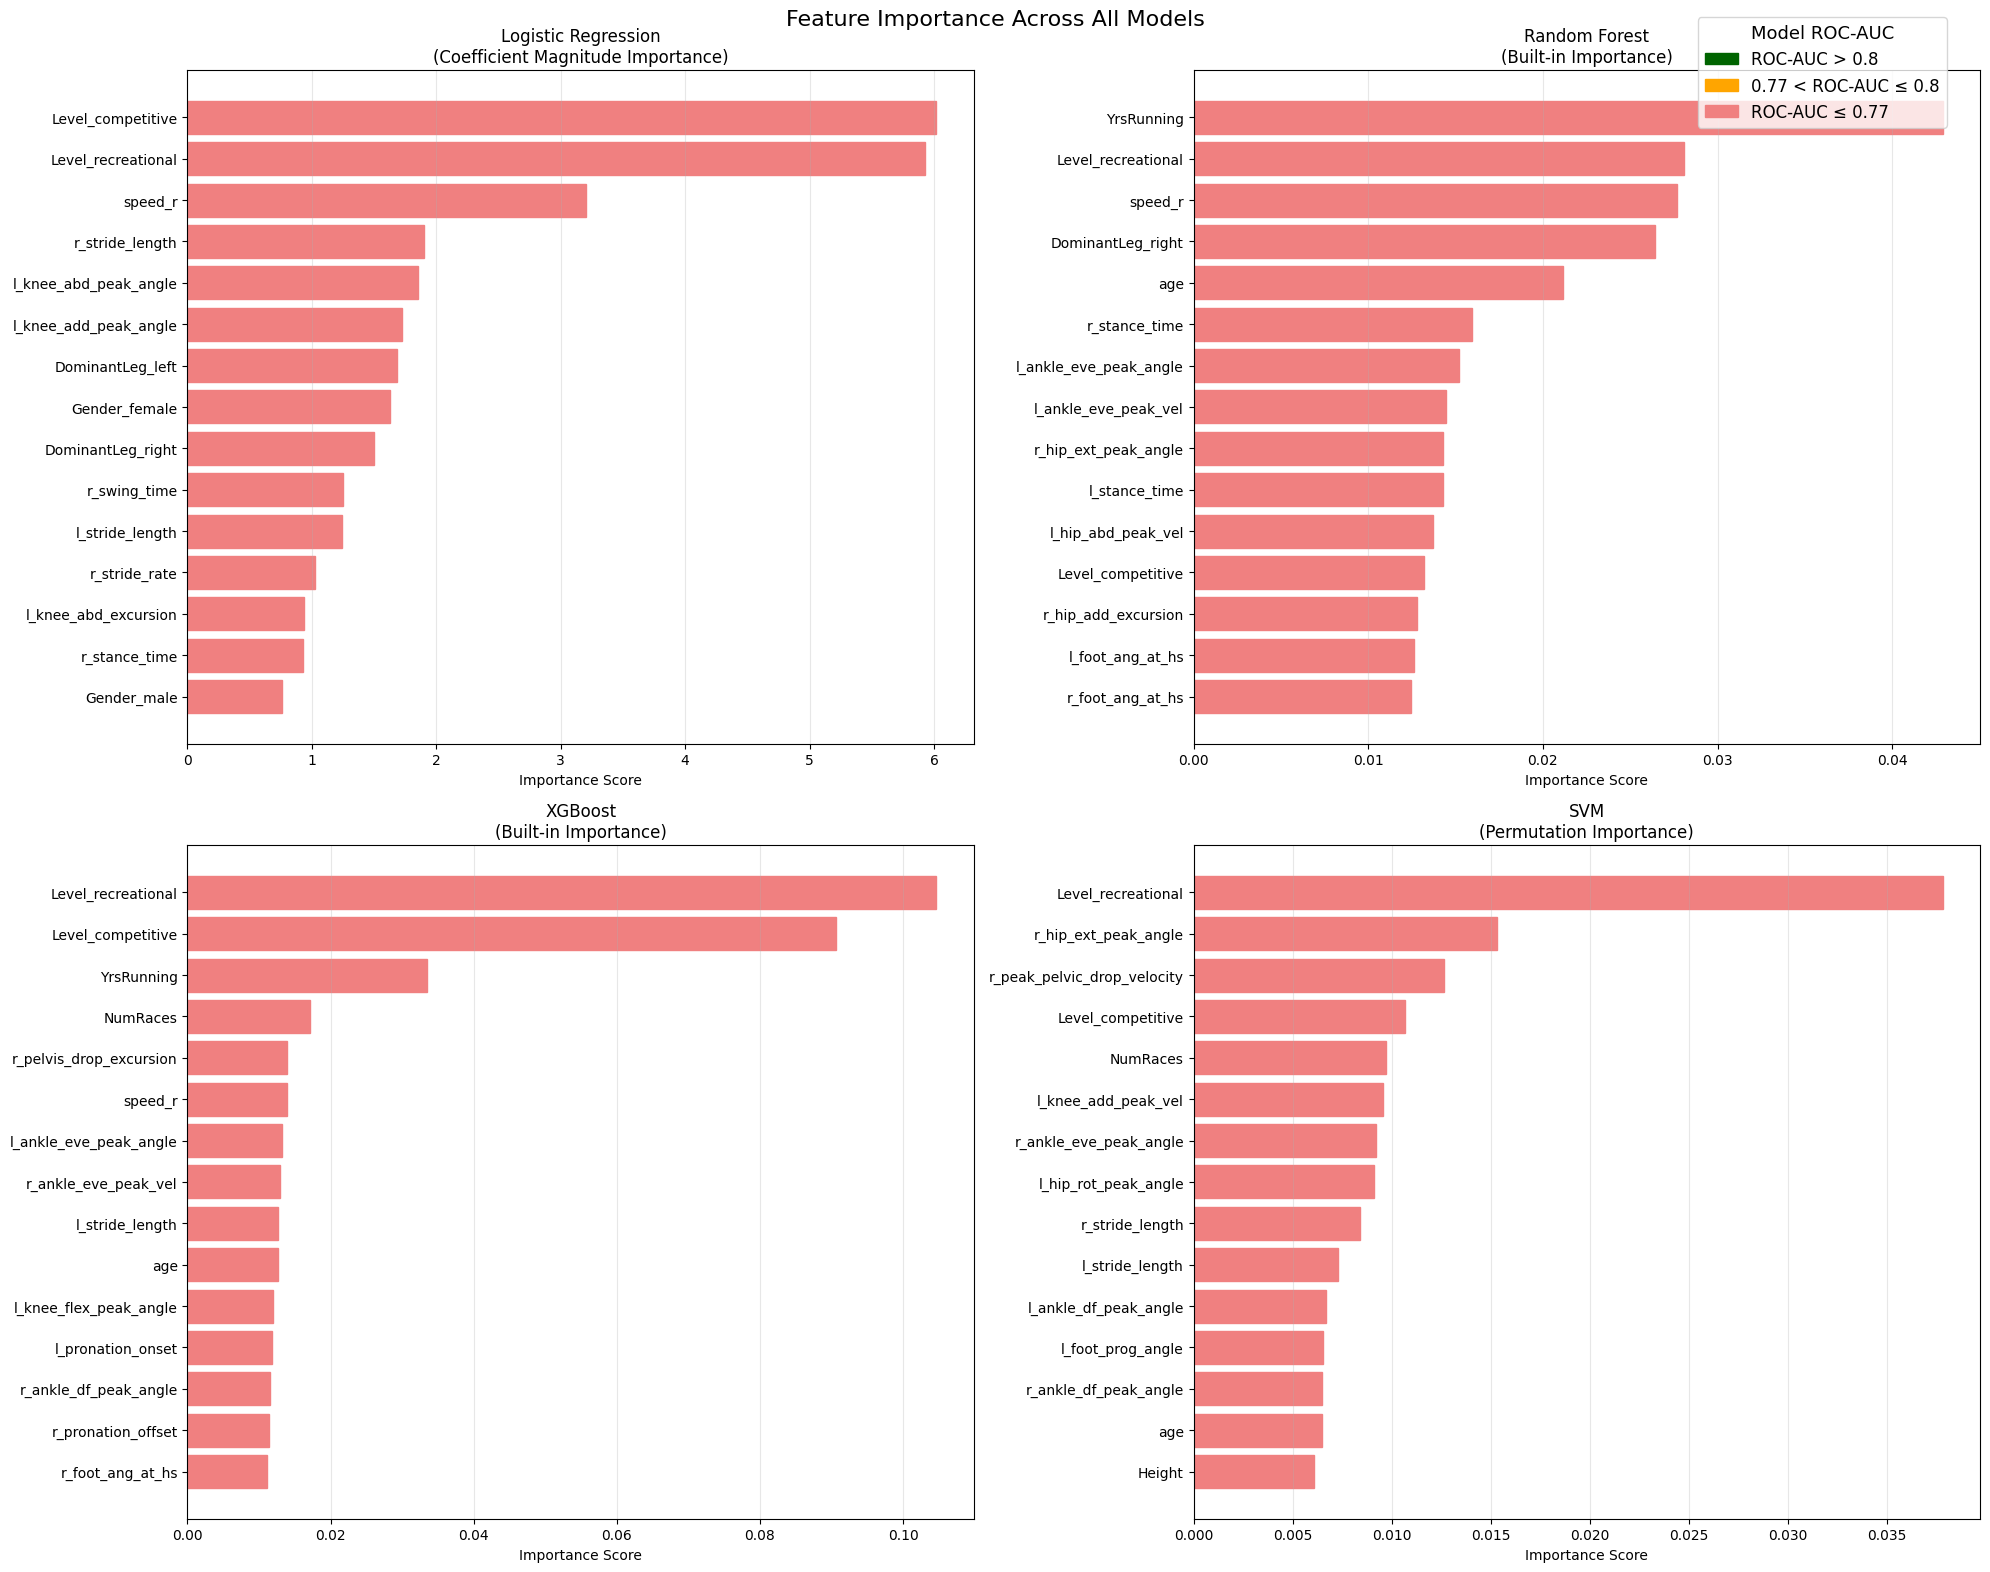

In [5]:
plot_feature_importances_by_model(all_feature_importance, results, top_n=15, figsize=(20, 16))

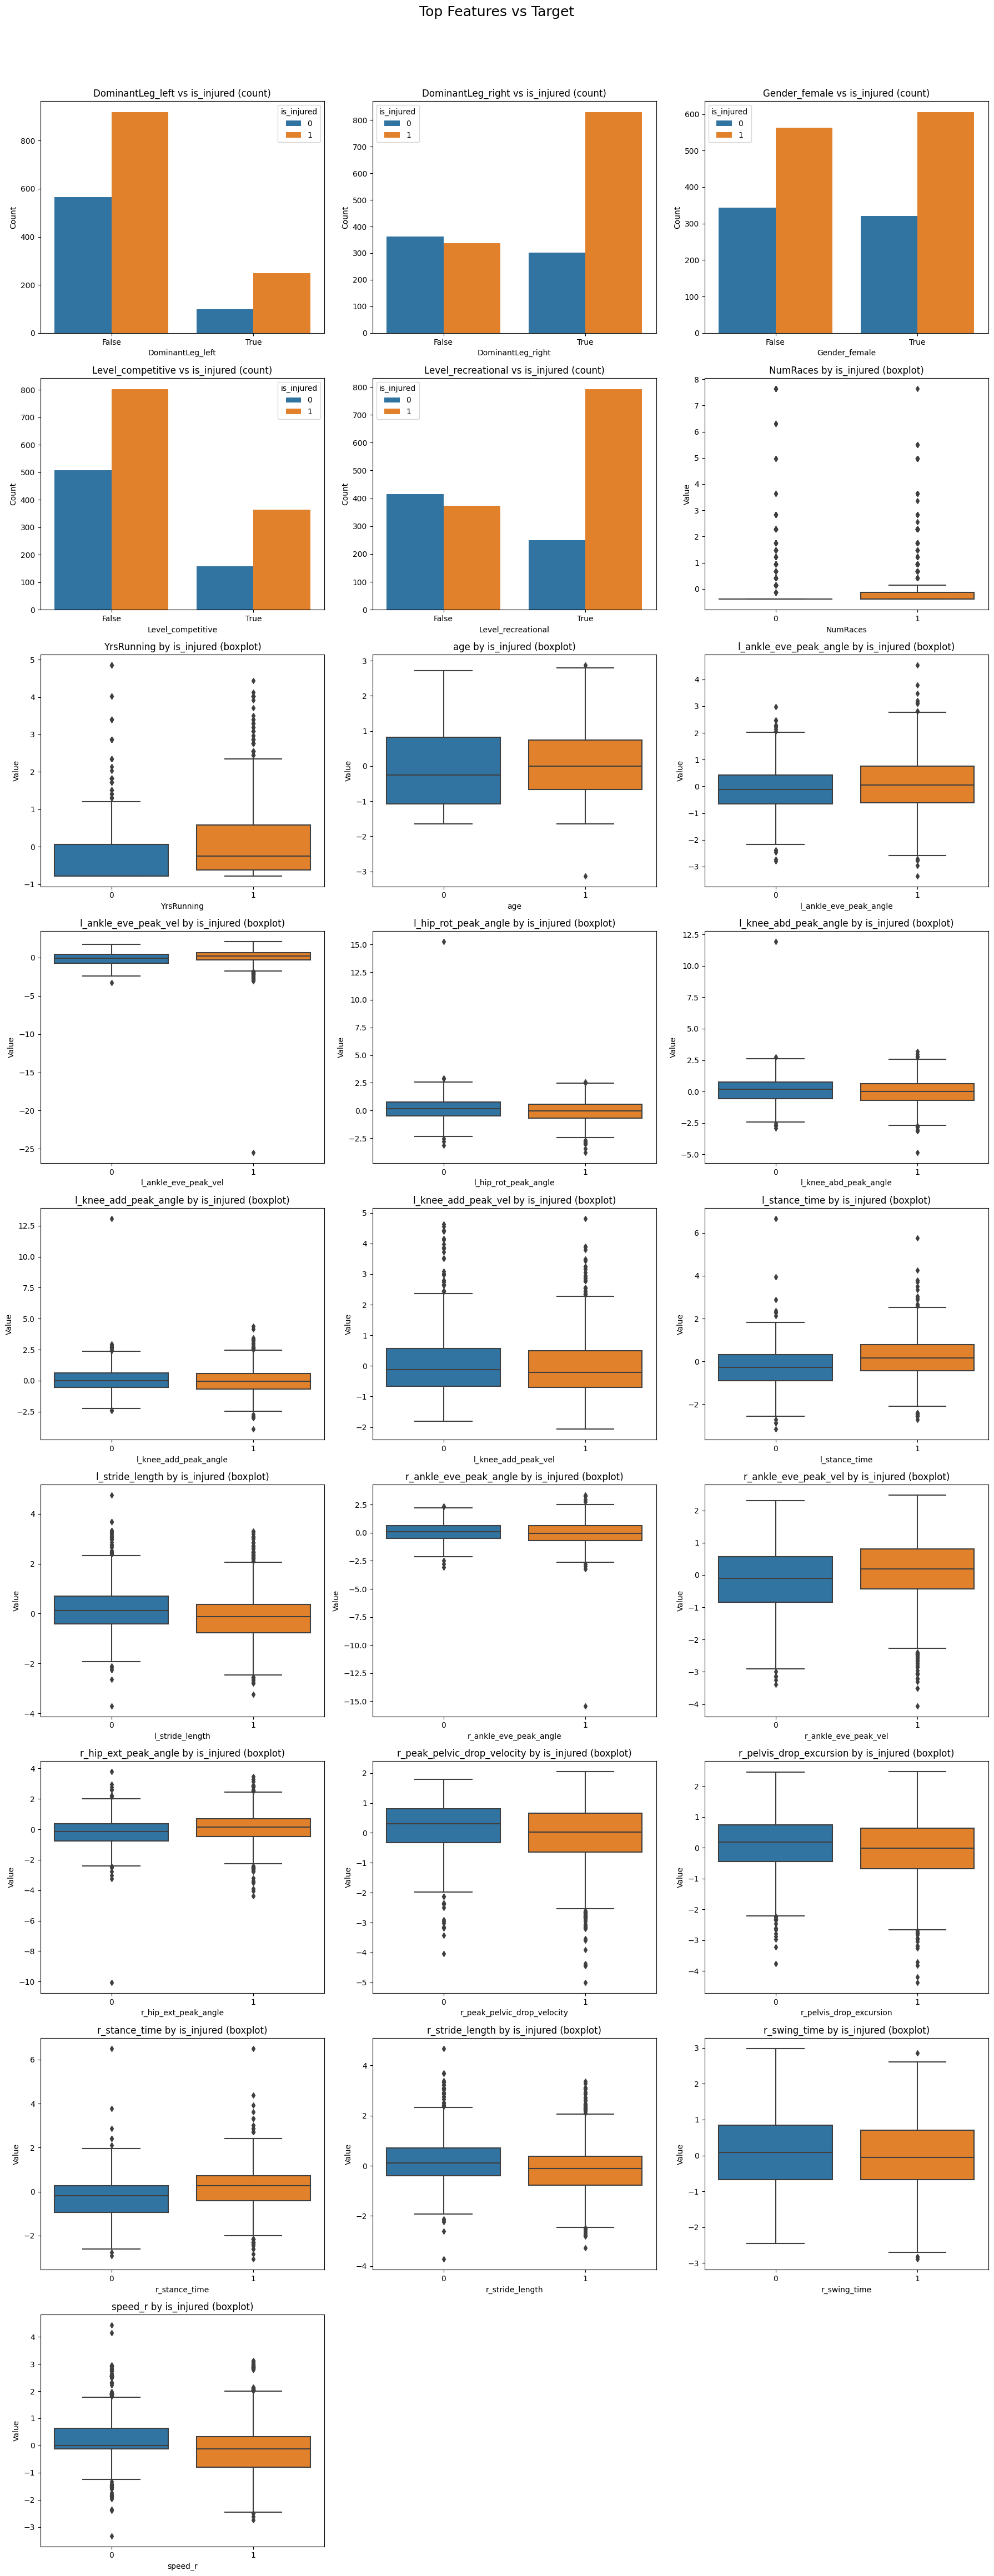

In [6]:
X = pd.read_csv(c.RICKD_BASELINE_X_FILE, index_col=0)
y = pd.read_csv(c.RICKD_BASELINE_Y_FILE, index_col=0)


# Collect top 10 features for each model based on importance
top_features_to_check = set()
for model_name, importance_df in all_feature_importance.items():
    top_features = importance_df.sort_values("importance", ascending=False).head(10)["feature"]
    top_features_to_check.update(top_features)

top_features_to_check = list(top_features_to_check)
top_features_to_check.sort()

plot_feature_vs_target_grid(
    X=X,
    y=y,
    features=top_features_to_check,
    target_col='is_injured',
    n_cols=3,
    figsize_per_cell=(6, 5),
)